In [1]:
import torch
import torchvision
from torch import nn


def conv3x3(i: int, o: int) -> nn.Conv2d:
    """3×3 convolution with padding=1 (same spatial size)."""
    return nn.Conv2d(i, o, kernel_size=3, padding=1, bias=False)


class ConvGelu(nn.Module):
    """Conv → GELU helper block (replacing Conv+ReLU)."""

    def __init__(self, i: int, o: int):
        super().__init__()
        self.block = nn.Sequential(
            conv3x3(i, o),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    """Decoder up‑sampling block: (Conv→GELU) ×1  +  2× upsample via transpose‑conv."""

    def __init__(self, i: int, m: int, o: int):
        super().__init__()
        self.block = nn.Sequential(
            ConvGelu(i, m),
            nn.ConvTranspose2d(m, o, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class InvertedBottleneck(nn.Module):
    """MobileNet‑v2 style inverted residual bottleneck.

    Args:
        ch (int): input/output channels.
        exp (int): expansion factor. Default 4 (i.e. ch → ch*exp → ch).
    """

    def __init__(self, ch: int, exp: int = 4):
        super().__init__()
        mid = ch * exp
        self.block = nn.Sequential(
            # 1×1 point‑wise expansion
            nn.Conv2d(ch, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid),
            nn.GELU(),
            # 3×3 depth‑wise conv
            nn.Conv2d(mid, mid, kernel_size=3, padding=1, groups=mid, bias=False),
            nn.BatchNorm2d(mid),
            nn.GELU(),
            # 1×1 point‑wise projection back
            nn.Conv2d(mid, ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(ch),
        )

    def forward(self, x):
        return x + self.block(x)  # residual connection


class UNet11_4ch(nn.Module):
    """UNet‑11 backbone with 4‑channel input, GELU activations, and an extra inverted bottleneck before the final head."""

    def __init__(self, num_filters: int = 32, pretrained: bool = True):
        super().__init__()

        # ─────── Encoder (VGG11) ────────────────────────────────────────────
        enc = torchvision.models.vgg11(pretrained=pretrained).features

        # First conv: 4→64 (copy RGB weights and set 4th channel to mean)
        old_conv1 = enc[0]  # 3→64
        new_conv1 = nn.Conv2d(4, 64, kernel_size=3, padding=1, bias=False)
        if pretrained:
            with torch.no_grad():
                new_conv1.weight[:, :3] = old_conv1.weight  # copy RGB
                new_conv1.weight[:, 3:4] = old_conv1.weight.mean(dim=1, keepdim=True)
        enc[0] = new_conv1
        self.encoder = enc  # keep as torch.nn.Sequential

        # Shortcut handles
        self.gelu = nn.GELU()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv1, self.conv2 = enc[0], enc[3]
        self.conv3s, self.conv3 = enc[6], enc[8]
        self.conv4s, self.conv4 = enc[11], enc[13]
        self.conv5s, self.conv5 = enc[16], enc[18]

        # ─────── Decoder ──────────────────────────────────────────────────
        nf = num_filters
        self.center = DecoderBlock(nf * 8 * 2, nf * 8 * 2, nf * 8)
        self.dec5 = DecoderBlock(nf * (16 + 8), nf * 8 * 2, nf * 8)
        self.dec4 = DecoderBlock(nf * (16 + 8), nf * 8 * 2, nf * 4)
        self.dec3 = DecoderBlock(nf * (8 + 4), nf * 4 * 2, nf * 2)
        self.dec2 = DecoderBlock(nf * (4 + 2), nf * 2 * 2, nf)
        self.dec1 = ConvGelu(nf * (2 + 1), nf)

        # ─────── Inverted Bottleneck  +  Final head ────────────────────────
        self.inv = InvertedBottleneck(nf, exp=4)
        self.final = nn.Conv2d(nf, 1, kernel_size=1)

    # ---------------------------------------------------------------------
    def _enc_forward(self, x):
        c1 = self.gelu(self.conv1(x))
        c2 = self.gelu(self.conv2(self.pool(c1)))
        c3s = self.gelu(self.conv3s(self.pool(c2)))
        c3 = self.gelu(self.conv3(c3s))
        c4s = self.gelu(self.conv4s(self.pool(c3)))
        c4 = self.gelu(self.conv4(c4s))
        c5s = self.gelu(self.conv5s(self.pool(c4)))
        c5 = self.gelu(self.conv5(c5s))
        return c1, c2, c3, c4, c5

    def forward(self, x):
        c1, c2, c3, c4, c5 = self._enc_forward(x)
        ctr = self.center(self.pool(c5))

        d5 = self.dec5(torch.cat([ctr, c5], dim=1))
        d4 = self.dec4(torch.cat([d5, c4], dim=1))
        d3 = self.dec3(torch.cat([d4, c3], dim=1))
        d2 = self.dec2(torch.cat([d3, c2], dim=1))
        d1 = self.dec1(torch.cat([d2, c1], dim=1))

        out = self.inv(d1)  # apply inverted bottleneck residual block
        return self.final(out)




In [2]:
# train_unet4ch.py
import os, csv, random, argparse
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import torch, torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader
#from model import UNet11_4ch                 # ★★ 改成 4ch 版本

# ---------------- Dataset ----------------
class AerialPatchDataset4C(Dataset):
    """
    root/
     ├─ images/        austin1.tif ...
     ├─ depth_images/  austin1_depth.png / tif / jpg ...
     └─ gt/            austin1.tif (遮罩，與 images 同名)
    """
    COMMON_EXTS = [".png", ".jpg", ".jpeg", ".tif", ".tiff"]

    def __init__(self, root, crop=256):
        self.crop      = crop
        self.img_dir   = os.path.join(root, "images")
        self.depth_dir = os.path.join(root, "depth_images")
        self.mask_dir  = os.path.join(root, "gt")

        self.names     = sorted(os.listdir(self.img_dir))           # ex: austin1.tif
        self.depth_map = self._build_depth_map()                    # ★★ 建對應表

        self.mean = torch.tensor([0.485,0.456,0.406,0.5]).view(4,1,1)
        self.std  = torch.tensor([0.229,0.224,0.225,0.5]).view(4,1,1)

    # ----------  新增：掃描 depth_images ----------
    def _build_depth_map(self):
        depth_files = os.listdir(self.depth_dir)
        depth_dict  = {}
        for f in depth_files:
            stem, ext = os.path.splitext(f)
            if stem.endswith("_depth"):
                base = stem[:-6]                    # 去掉 "_depth"
                depth_dict[base] = f
        return depth_dict                           # {austin1: austin1_depth.png}

    def __len__(self): return len(self.names)

    def _random_crop(self, img, depth, msk):
        h, w = img.shape[:2]; ch = cw = self.crop
        top  = random.randint(0, h - ch); left = random.randint(0, w - cw)
        return (arr[top:top+ch, left:left+cw] for arr in (img, depth, msk))

    def __getitem__(self, idx):
        name = self.names[idx]                      # austin1.tif
        stem, ext = os.path.splitext(name)          # austin1, .tif
        try:
            # --- 找對應的深度圖檔名 ---
            if stem in self.depth_map:
                depth_fname = self.depth_map[stem]
            else:
                # 保險：按副檔名猜測
                depth_fname = None
                for ex in [ext] + self.COMMON_EXTS:
                    cand = f"{stem}_depth{ex}"
                    if os.path.exists(os.path.join(self.depth_dir, cand)):
                        depth_fname = cand; break
                if depth_fname is None:
                    raise FileNotFoundError(f"找不到 {stem}_depth.*")

            # --- 讀檔 ---
            rgb   = Image.open(os.path.join(self.img_dir,   name)).convert("RGB")
            depth = Image.open(os.path.join(self.depth_dir, depth_fname)).convert("L")
            msk   = Image.open(os.path.join(self.mask_dir,  name)).convert("L")

            rgb   = np.asarray(rgb)
            depth = np.asarray(depth)[..., None]              # H×W×1
            msk   = (np.asarray(msk) // 255).astype(np.uint8)

            rgb, depth, msk = self._random_crop(rgb, depth, msk)

            # --- to tensor ---
            rgb   = torch.from_numpy(rgb).permute(2,0,1).float() / 255.0
            depth = torch.from_numpy(depth).permute(2,0,1).float() / 255.0
            img4  = torch.cat([rgb, depth], 0)                # 4×H×W
            img4  = (img4 - self.mean) / self.std
            msk   = torch.from_numpy(msk).float().unsqueeze(0)
            return img4, msk

        except Exception as e:
            print(f"❌ [錯誤] {name}: {e}")
            return (torch.zeros(4, self.crop, self.crop),
                    torch.zeros(1, self.crop, self.crop))

# ---------------- Metric -----------------
def dice_coef(pred, target, eps=1e-7):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum((1,2,3))
    union = pred.sum((1,2,3)) + target.sum((1,2,3))
    return ((2*inter+eps)/(union+eps)).mean()

# ---------------- Train ------------------
def main(args):
    torch.multiprocessing.set_start_method('spawn', force=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("🚀 Device:", device)

    root = r"E:\論文\空拍地圖語意分割\Depth4UNet\AerialImageDataset\train"
    if not os.path.exists(root):
        print(f"❌ 找不到資料目錄 {root}"); return

    data = AerialPatchDataset4C(root, crop=args.crop)
    print(f"📊 共 {len(data)} 張影像")
    v = int(0.1*len(data))
    train_ds, val_ds = torch.utils.data.random_split(data, [len(data)-v, v])

    def loader(ds, shf): return DataLoader(
        ds, batch_size=args.bs, shuffle=shf,
        num_workers=0, pin_memory=False, persistent_workers=False)

    train_ld, val_ld = loader(train_ds, True), loader(val_ds, False)

    model = UNet11_4ch(pretrained=True).to(device)      # ★★
    crit  = nn.BCEWithLogitsLoss()
    opt   = torch.optim.Adam(model.parameters(), lr=args.lr)
    scaler= torch.amp.GradScaler(device.type)

    best = 0; os.makedirs("checkpoints", exist_ok=True)
    with open("metrics.csv","w",newline="") as f:
        csv.writer(f).writerow(["epoch","train_loss","val_loss","dice"])

    for ep in range(1, args.epochs+1):
        # ---- train ----
        model.train(); tr_loss=0; n_tr=0
        for img,msk in tqdm(train_ld, desc=f"Ep{ep}/{args.epochs} train"):
            img,msk = img.to(device), msk.to(device)
            with torch.amp.autocast(device.type):
                pred = model(img); loss = crit(pred, msk)
            opt.zero_grad(); scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            tr_loss += loss.item(); n_tr += 1

        # ---- val ----
        model.eval(); vl_loss=0; dices=[]; n_v=0
        with torch.no_grad():
            for img,msk in tqdm(val_ld, desc=f"Ep{ep}/{args.epochs} val"):
                img,msk = img.to(device), msk.to(device)
                with torch.amp.autocast(device.type):
                    pred = model(img); loss = crit(pred, msk)
                vl_loss += loss.item(); dices.append(dice_coef(pred, msk).item()); n_v += 1

        tr_loss /= max(n_tr,1); vl_loss /= max(n_v,1); dice = np.mean(dices) if dices else 0
        print(f"📝 Ep{ep} train={tr_loss:.4f} val={vl_loss:.4f} dice={dice:.4f}")
        with open("metrics.csv","a",newline="") as f:
            csv.writer(f).writerow([ep,tr_loss,vl_loss,dice])

        if dice > best:
            best = dice
            torch.save(model.state_dict(), "checkpoints/best_unet4ch(GELU).pth")
            print(f"  👑  Saved best model (dice {best:.4f})")

# ---------------- Run --------------------
if __name__ != "__main__":
    args = argparse.Namespace(epochs=100, bs=4, lr=1e-4, crop=256)
    main(args)


c:\Users\op237\miniconda3\envs\Depth4UNet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Device: cuda


c:\Users\op237\miniconda3\envs\Depth4UNet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\op237\miniconda3\envs\Depth4UNet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\op237\AppData\Local\Temp\ipykernel_22792\481458458.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value

UNet4ch: matched 61 / 61 layers


Infer val: 100%|██████████| 5/5 [00:21<00:00,  4.40s/it]


Collected 1,179,648 pixels for evaluation
Average Precision = 0.8626
📈  Saved pr_curve.png
💾  Saved val_pred.npz


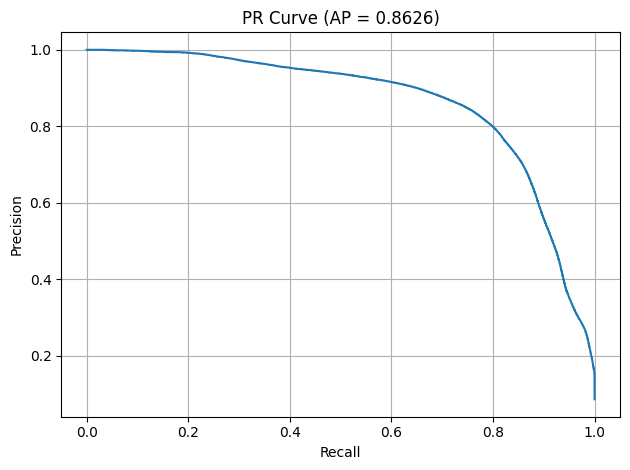

In [ ]:
# %% [markdown]
# # Evaluate **UNet11_4ch** & Plot Precision-Recall Curve
#
# 1. 先設定 `CKPT_PATH` 與 `DATA_ROOT`  
# 2. Run all cells / 執行整支 script  
# 3. 會列出 matched layers、計算 PR 曲線與 AP，並存出
#    * `pr_curve.png`
#    * `val_pred.npz`

# %% [markdown]
# ## （可選）安裝相依套件
# 如果缺 `scikit-learn` / `matplotlib`，取消註解以下一行安裝
# !pip install scikit-learn matplotlib tqdm
# ── 固定隨機種子，請放在 import 後、任何資料集/模型建立之前 ──
import random, numpy as np, torch

SEED = 107               # 你想用的種子數
random.seed(SEED)       # Python 內建 random
np.random.seed(SEED)    # NumPy
torch.manual_seed(SEED) # PyTorch CPU
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)      # PyTorch GPU
torch.backends.cudnn.deterministic = True # 讓 cuDNN 算子 deterministic
torch.backends.cudnn.benchmark = False    # 關掉自適應演算法選擇

# %% Imports & helpers
import os, torch, numpy as np, matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import precision_recall_curve, average_precision_score

# ---- 匯入你的模型與 Dataset ----


def load_ckpt(model, ckpt_path, label="UNet4ch"):
    """安全載入權重並回報相符層數"""
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model_state = model.state_dict()
    compatible = {k: v for k, v in ckpt.items()
                  if k in model_state and v.shape == model_state[k].shape}
    model_state.update(compatible)
    model.load_state_dict(model_state)
    print(f"{label}: matched {len(compatible)} / {len(model_state)} layers")
    return model

# %% 🔧 路徑與參數（請修改這裡）
CKPT_PATH  = r"checkpoints/best_unet4ch(GELU).pth"  # ← 你的 checkpoint
DATA_ROOT  = r"E:\論文\空拍地圖語意分割\Depth4UNet\AerialImageDataset\train"  # ← 資料集根目錄
BATCH_SIZE = 4
CROP_SIZE  = 256
VAL_RATIO  = 0.10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🚀 Device:", device)

# %% Dataset & DataLoader
ds = AerialPatchDataset4C(DATA_ROOT, crop=CROP_SIZE)
val_len = int(len(ds) * VAL_RATIO)
_, val_ds = torch.utils.data.random_split(ds, [len(ds) - val_len, val_len])

val_ld = torch.utils.data.DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False)

# %% Model
model = UNet11_4ch(pretrained=False).to(device)
model = load_ckpt(model, CKPT_PATH)

# %% Inference: collect y_true / y_score
model.eval()
y_true, y_score = [], []
with torch.no_grad():
    for img, msk in tqdm(val_ld, desc="Infer val"):
        img = img.to(device)
        prob = model(img).sigmoid().cpu()   # (B,1,H,W) 機率
        y_score.append(prob.flatten())
        y_true.append(msk.flatten())

y_true  = torch.cat(y_true).numpy()
y_score = torch.cat(y_score).numpy()
print(f"Collected {y_true.shape[0]:,} pixels for evaluation")

# %% PR curve & Average Precision
precision, recall, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)
print(f"Average Precision = {ap:.4f}")

# %% Plot & save
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (AP = {ap:.4f})")
plt.grid()
plt.tight_layout()
plt.savefig("VGG11.png")
print("📈  Saved pr_curve.png")

# Save raw arrays
np.savez_compressed("val_pred.npz", y_true=y_true, y_score=y_score)
print("💾  Saved val_pred.npz")


In [ ]:
# %% PR curve & Average Precision
from sklearn.metrics import precision_recall_curve, average_precision_score
import pandas as pd

precision, recall, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)
print(f"Average Precision = {ap:.4f}")

# 存成 CSV（不含 Threshold）
pr_df = pd.DataFrame({
    "Precision": precision,
    "Recall": recall
})
pr_df.to_csv("UNetVGG11_invertedbottleneck.csv", index=False)
print("💾 Saved pr_curve.csv")

# %% Plot & save
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (AP = {ap:.4f})")
plt.grid()
plt.tight_layout()
plt.savefig("UNetVGG11_invertedbottleneck.png")
print("📈 Saved pr_curve.png")

# Save raw arrays
np.savez_compressed("val_pred.npz", y_true=y_true, y_score=y_score)
print("💾 Saved val_pred.npz")
